In [ ]:
# =============================================
# 📌 Supporting Analytical Techniques with Deep Learning
# Google Colab Notebook (Fixed - No PDPBox)
# =============================================

# Install required packages
!pip install imbalanced-learn shap scikit-plot optuna -q

# ---------------------------------------------
# 1. Import Libraries
# ---------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

import shap

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# ---------------------------------------------
# 2. Load Dataset
# ---------------------------------------------
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

print("Shape:", df.shape)
display(df.head())

# ---------------------------------------------
# 3. Preprocessing
# ---------------------------------------------
# Drop 'Image' column (not a feature)
if 'Image' in df.columns:
    df = df.drop(columns=['Image'])

X = df.drop(columns=['Class'])
y = df['Class']

# Check imbalance
print("Class distribution:\n", y.value_counts())

# Balance dataset with SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

# Normalize features
scaler = StandardScaler()
X_res = scaler.fit_transform(X_res)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

# ---------------------------------------------
# 4. Exploratory Data Analysis (EDA)
# ---------------------------------------------
# Correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(pd.DataFrame(X, columns=df.columns[:-1]).corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Scatter plot example
if 'Mean' in df.columns and 'Variance' in df.columns:
    sns.scatterplot(x=df['Mean'], y=df['Variance'], hue=df['Class'], alpha=0.6)
    plt.title("Scatter Plot: Mean vs Variance")
    plt.show()

# ---------------------------------------------
# 5. Deep Learning Model
# ---------------------------------------------
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[es],
    verbose=1
)

# Evaluate
y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# ---------------------------------------------
# 6. Explainable AI (XAI) - SHAP Only
# ---------------------------------------------
# SHAP (KernelExplainer works on CPU and with non-tree models)
explainer = shap.KernelExplainer(model.predict, X_train[:100])
shap_values = explainer.shap_values(X_test[:50])

# SHAP summary plot
shap.summary_plot(shap_values, X_test[:50], feature_names=df.columns[:-1])

# ---------------------------------------------
# 7. Hyperparameter Tuning (Optuna Example)
# ---------------------------------------------
import optuna

def objective(trial):
    units1 = trial.suggest_int("units1", 32, 128)
    units2 = trial.suggest_int("units2", 16, 64)
    dropout = trial.suggest_float("dropout", 0.2, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    model_tune = Sequential([
        Dense(units1, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(dropout),
        Dense(units2, activation='relu'),
        Dropout(dropout),
        Dense(1, activation='sigmoid')
    ])

    model_tune.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                       loss='binary_crossentropy', metrics=['accuracy'])

    history_tune = model_tune.fit(X_train, y_train, validation_split=0.2,
                                  epochs=30, batch_size=batch_size, verbose=0)
    val_acc = max(history_tune.history['val_accuracy'])
    return val_acc

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Best hyperparameters:", study.best_params)


Saving Brain Tumor.csv to Brain Tumor (1).csv
Shape: (3762, 15)


,Image,Class,Mean,Variance,Standard Deviation,Entropy,Skewness,Kurtosis,Contrast,Energy,ASM,Homogeneity,Dissimilarity,Correlation,Coarseness
0,Image1,0,6.535339,619.587845,24.891522,0.109059,4.276477,18.900575,98.613971,0.293314,0.086033,0.530941,4.473346,0.981939,7.458341e-155
1,Image2,0,8.749969,805.957634,28.389393,0.266538,3.718116,14.464618,63.858816,0.475051,0.225674,0.651352,3.220072,0.988834,7.458341e-155
2,Image3,1,7.341095,1143.808219,33.820234,0.001467,5.061750,26.479563,81.867206,0.031917,0.001019,0.268275,5.981800,0.978014,7.458341e-155
3,Image4,1,5.958145,959.711985,30.979219,0.001477,5.677977,33.428845,151.229741,0.032024,0.001026,0.243851,7.700919,0.964189,7.458341e-155
4,Image5,0,7.315231,729.540579,27.010009,0.146761,4.283221,19.079108,174.988756,0.343849,0.118232,0.501140,6.834689,0.972789,7.458341e-155


Class distribution:
 Class
0    2079
1    1683
Name: count, dtype: int64


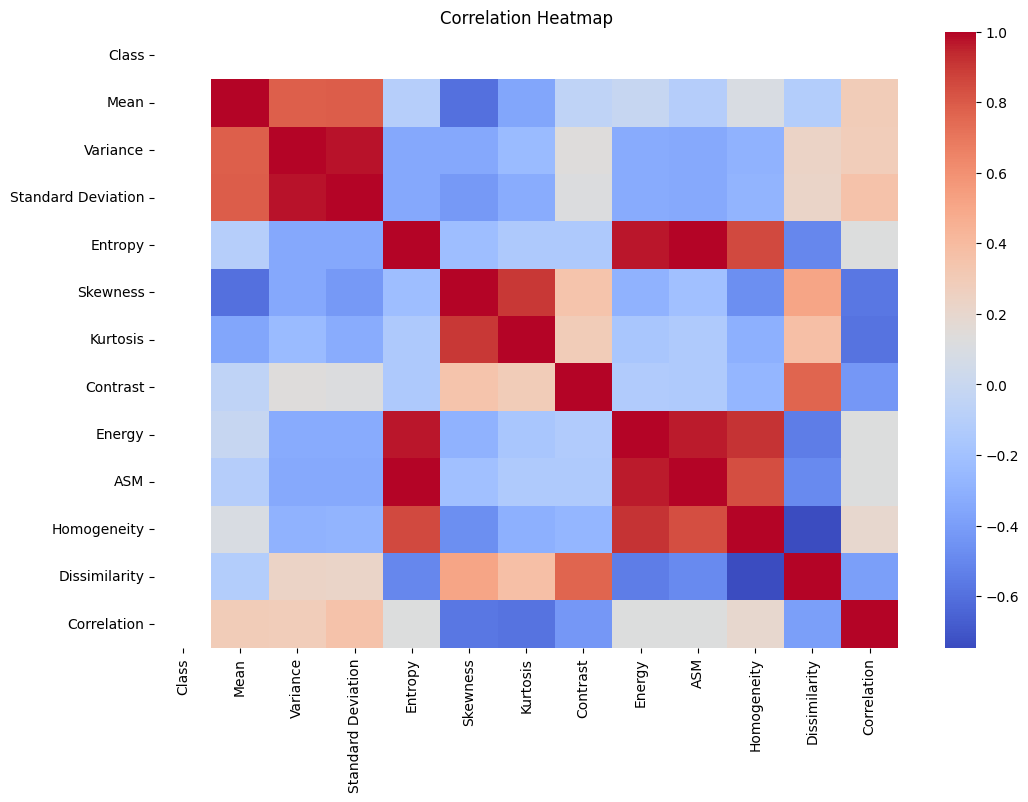

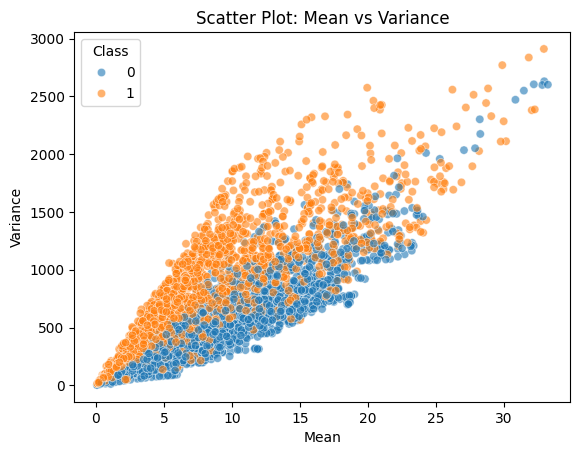

Epoch 1/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7758 - loss: 0.4769 - val_accuracy: 0.9760 - val_loss: 0.2621
Epoch 2/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9646 - loss: 0.1166 - val_accuracy: 0.9880 - val_loss: 0.1030
Epoch 3/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9694 - loss: 0.1044 - val_accuracy: 0.9820 - val_loss: 0.0632
Epoch 4/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9704 - loss: 0.0866 - val_accuracy: 0.9895 - val_loss: 0.0493
Epoch 5/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9727 - loss: 0.0742 - val_accuracy: 0.9895 - val_loss: 0.0449
Epoch 6/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9788 - loss: 0.0722 - val_accuracy: 0.9880 - val_loss: 0.0417
Epoch 7/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9810 - loss: 0.0653 - val_accuracy: 0.9880 - val_loss: 0.0392
Epoch 8/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9782 - loss: 0.0631 - val_accuracy: 0.9880 - 

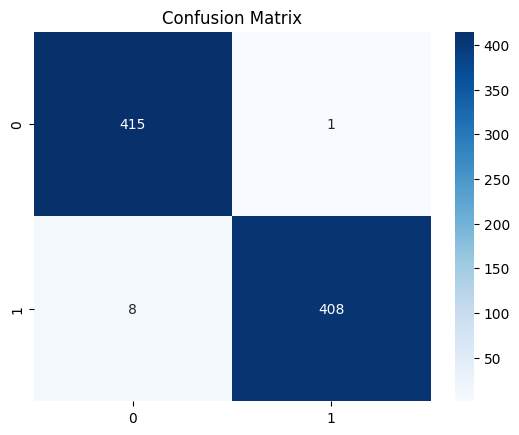

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


  0%|          | 0/50 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
6475/6475 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
6475/6475 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
6475/6475 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
6475/6475 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
6475/6475 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
6475/6475 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
6475/6475 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
6475/6475 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
6475/6475 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
6475/6475 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
6475/6475 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
6475/6475 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

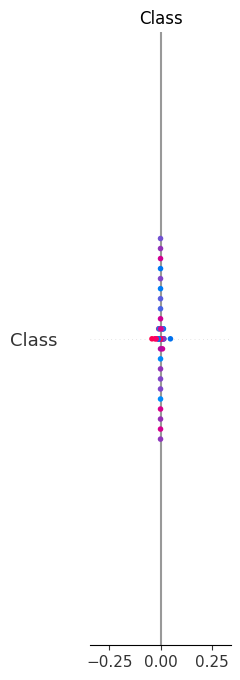

[I 2025-09-22 12:37:58,745] A new study created in memory with name: no-name-cd4cf270-2ec0-4b15-8919-4111d2aacecc
[I 2025-09-22 12:38:20,313] Trial 0 finished with value: 0.9924924969673157 and parameters: {'units1': 55, 'units2': 33, 'dropout': 0.4775474046414045, 'lr': 0.001808626086209076, 'batch_size': 16}. Best is trial 0 with value: 0.9924924969673157.
[I 2025-09-22 12:38:42,629] Trial 1 finished with value: 0.9939939975738525 and parameters: {'units1': 94, 'units2': 51, 'dropout': 0.37493655584942553, 'lr': 0.0007557954992666571, 'batch_size': 16}. Best is trial 1 with value: 0.9939939975738525.
[I 2025-09-22 12:39:04,035] Trial 2 finished with value: 0.9909909963607788 and parameters: {'units1': 95, 'units2': 48, 'dropout': 0.24827200439632796, 'lr': 0.00043534338475926794, 'batch_size': 16}. Best is trial 1 with value: 0.9939939975738525.
[I 2025-09-22 12:39:14,523] Trial 3 finished with value: 0.9924924969673157 and parameters: {'units1': 53, 'units2': 29, 'dropout': 0.397042

Best hyperparameters: {'units1': 94, 'units2': 51, 'dropout': 0.37493655584942553, 'lr': 0.0007557954992666571, 'batch_size': 16}
